<a href="https://colab.research.google.com/github/Sultonmahmudov/week1-lab201/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a id="toc"></a>

# Polynomial Regression and Regularization


---

## Table of Contents

- [Introduction](#introduction)
- [Part 1: Detailed Tutorial](#part-1-detailed-tutorial)
  - [1.1 Linear vs Polynomial Regression](#11-linear-vs-polynomial-regression)
  - [1.2 Polynomial Features & Overfitting](#12-polynomial-features--overfitting)
  - [1.3 Regularization: Ridge, Lasso, Elastic Net](#13-regularization-ridge-lasso-elastic-net)
  - [1.4 Hyperparameter Tuning with Cross-Validation](#14-hyperparameter-tuning-with-cross-validation)
- [Part 2: Coding Tasks (100 marks)](#part-2-coding-tasks-100-marks)
- [Bonus Section (10% extra marks)](#bonus-section-10-extra-marks)
- [Conclusion](#conclusion)
- [Submission](#submission)

[↑ Back to top](#toc)

---

<a id="introduction"></a>

## Introduction

### Learning objectives

By the end of this lab, you should be able to:

- Explain when linear models fail for nonlinear data and how polynomial feature expansion helps.
- Fit polynomial regression models in `scikit-learn` and diagnose **overfitting** using train vs test error.
- Describe **Ridge (L2)**, **Lasso (L1)**, and **Elastic Net** penalties in words and equations, and interpret coefficient shrinkage and sparsity.
- Tune hyperparameters such as **polynomial degree** and **regularization strength** using **cross-validation** (`RidgeCV`, `LassoCV`, `GridSearchCV` on `Pipeline`).
- Communicate results with clear plots (titles, axis labels, legends, grids) and concise comparisons.


### Overview

You will work with a **single synthetic dataset** throughout the lab: a noisy sine curve. A simple linear model cannot capture the oscillation, so we expand inputs with `PolynomialFeatures`. High-degree polynomials can **overfit**; **regularization** trades off flexibility for stability. Finally, you will use **cross-validation** to pick hyperparameters responsibly and quantify generalization.

**Important:** The notebook performs one **70% train / 30% test** split at the start. **Reuse the same split** for every experiment unless a task explicitly asks otherwise.

[↑ Back to top](#toc)

In [1]:
%matplotlib inline

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    RidgeCV,
    LassoCV,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV, train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Consistent plotting style
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Reproducible synthetic dataset (used everywhere in this lab)
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.2, size=X.shape[0])

# Single train/test split for the whole notebook (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Sort test set for prettier plotting curves (optional; does not change metrics)
sort_idx = np.argsort(X_test.ravel())
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

X shape: (200, 1), y shape: (200,)
Train: 160 samples | Test: 40 samples


<a id="part-1-detailed-tutorial"></a>

# Part 1: Detailed Tutorial

This section is a guided walkthrough. Read the Markdown carefully, run each code cell in order, and connect the plots to the concepts (bias, variance, overfitting, regularization).

[↑ Back to top](#toc)

<a id="11-linear-vs-polynomial-regression"></a>

## 1.1 Linear vs Polynomial Regression

A **linear regression** model assumes the target is approximately an **affine function** of the input features:

$$
y \approx w_0 + \sum_{j=1}^{p} w_j x_j.
$$

When the true relationship is **nonlinear** (here, \(y \approx \sin(x)\)), a straight line is **structurally misspecified**: it has **high bias** for this problem, no matter how much data you collect.

**Polynomial regression** keeps a **linear model in the parameters** but augments the inputs with nonlinear transformations, e.g. \([x, x^2, x^3, ..]\). This can reduce bias, but overly rich expansions can **overfit** (high variance), which we address later with **regularization** and **model selection**.

Below, we fit ordinary least squares linear regression on the original 1D feature \(x\) and visualize **predictions** and **residuals**.

[↑ Back to top](#toc)

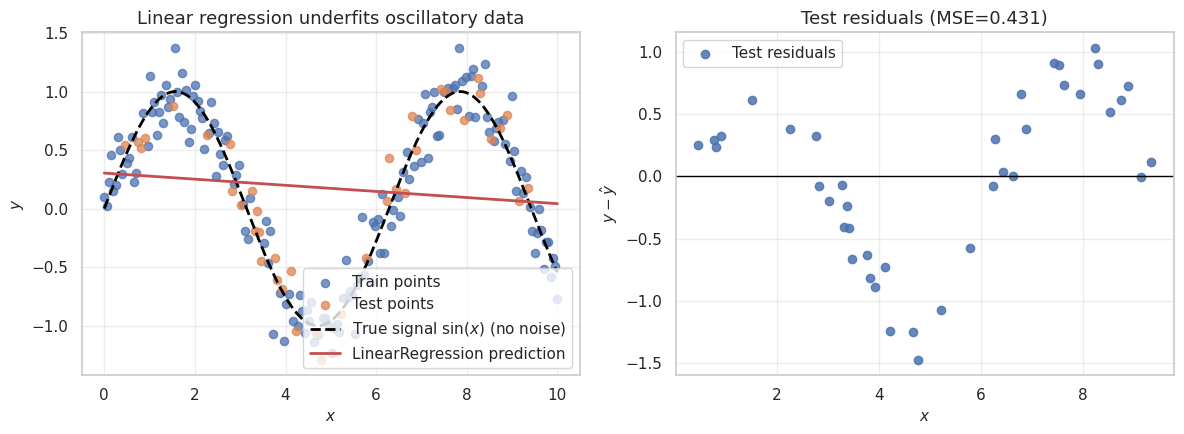

Train MSE: 0.4816 | Train R2: 0.0124
Test  MSE: 0.4310 | Test  R2: -0.0645


In [2]:
# 1.1 Linear regression on raw x (degree-1 feature space)
lin = LinearRegression()
lin.fit(X_train, y_train)

y_train_pred = lin.predict(X_train)
y_test_pred = lin.predict(X_test)

train_mse_lin = mean_squared_error(y_train, y_train_pred)
test_mse_lin = mean_squared_error(y_test, y_test_pred)

xx = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
yy_true = np.sin(xx).ravel()  # noise-free signal for reference
yy_hat = lin.predict(xx)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot A: data + linear fit vs underlying sine
axes[0].scatter(X_train, y_train, alpha=0.75, label="Train points", s=35)
axes[0].scatter(X_test, y_test, alpha=0.75, label="Test points", s=35)
axes[0].plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True signal $\\sin(x)$ (no noise)")
axes[0].plot(xx, yy_hat, color="C3", linewidth=2, label="LinearRegression prediction")
axes[0].set_title("Linear regression underfits oscillatory data")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.35)

# Plot B: residuals on the test set (sorted for readability)
residuals = y_test_sorted - lin.predict(X_test_sorted)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].scatter(X_test_sorted.ravel(), residuals, alpha=0.85, label="Test residuals")
axes[1].set_title(f"Test residuals (MSE={test_mse_lin:.3f})")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y - \\hat{y}$")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Train MSE: {train_mse:.4f} | Train R2: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f} | Test  R2: {test_r2:.4f}")

<a id="12-polynomial-features--overfitting"></a>

## 1.2 Polynomial Features & Overfitting Demonstration

We construct polynomial features with `PolynomialFeatures(degree=d)` and fit `LinearRegression` on the expanded design matrix. This is still **linear regression**, but in a higher-dimensional basis of monomials in \(x\).

### Bias–variance intuition (short)

- **Bias** measures systematic error from using a too-simple model family (underfitting).
- **Variance** measures sensitivity to training sample noise (overfitting).
- **Total error** often decomposes (conceptually) as **bias** + **variance** + irreducible noise; increasing \(d\) typically **reduces bias** but can **increase variance**.

We will compare degrees **1, 3, 8, 15, 30** and plot **train vs test MSE** vs degree.

[↑ Back to top](#toc)

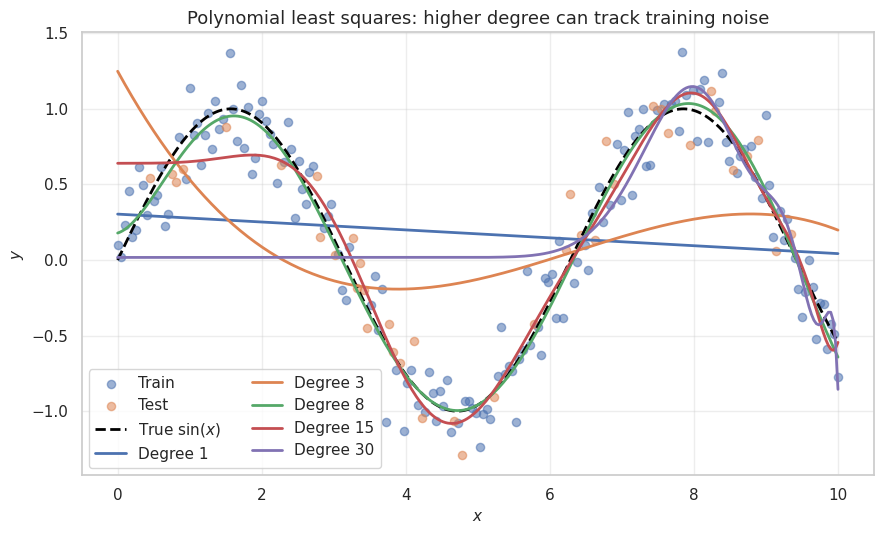

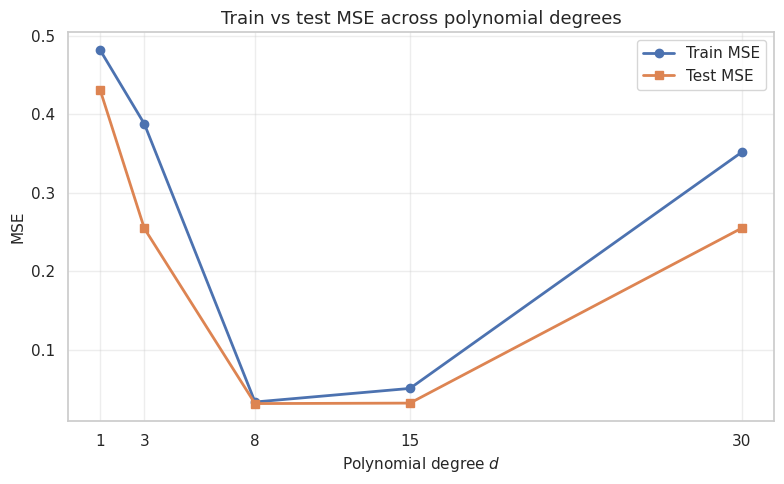

,degree,train_mse,test_mse
0,1,0.481618,0.430992
1,3,0.387548,0.254457
2,8,0.033575,0.031567
3,15,0.050863,0.032161
4,30,0.351704,0.254984


In [3]:
degrees_demo = [1, 3, 8, 15, 30]
models_by_degree = {}
train_mse_by_degree = []
test_mse_by_degree = []

for d in degrees_demo:
    poly = PolynomialFeatures(degree=d, include_bias=True)
    Xtr = poly.fit_transform(X_train)
    Xte = poly.transform(X_test)

    model = LinearRegression()
    model.fit(Xtr, y_train)
    models_by_degree[d] = (poly, model)

    train_mse_by_degree.append(mean_squared_error(y_train, model.predict(Xtr)))
    test_mse_by_degree.append(mean_squared_error(y_test, model.predict(Xte)))

# Figure 1: overlay polynomial fits
plt.figure(figsize=(9, 5.5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\\sin(x)$")

colors = sns.color_palette("deep", n_colors=len(degrees_demo))
for d, c in zip(degrees_demo, colors):
    poly, model = models_by_degree[d]
    Xx = poly.transform(xx)
    plt.plot(xx.ravel(), model.predict(Xx), linewidth=2, color=c, label=f"Degree {d}")

plt.title("Polynomial least squares: higher degree can track training noise")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best", ncol=2)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# Figure 2: train vs test MSE vs degree (learning-style diagnostic for this basis)
plt.figure(figsize=(8, 5))
plt.plot(degrees_demo, train_mse_by_degree, marker="o", linewidth=2, label="Train MSE")
plt.plot(degrees_demo, test_mse_by_degree, marker="s", linewidth=2, label="Test MSE")
plt.title("Train vs test MSE across polynomial degrees")
plt.xlabel("Polynomial degree $d$")
plt.ylabel("MSE")
plt.xticks(degrees_demo)
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

mse_table = pd.DataFrame(
    {"degree": degrees_demo, "train_mse": train_mse_by_degree, "test_mse": test_mse_by_degree}
)
mse_table

**Reading the plot:** when **train MSE** keeps dropping but **test MSE** worsens, the model is likely **overfitting**: it explains idiosyncratic noise in the training set rather than the stable structure of sin(x).

[↑ Back to top](#toc)

<a id="13-regularization-ridge-lasso-elastic-net"></a>

## 1.3 Regularization — Ridge (L2), Lasso (L1), and Elastic Net


### Ridge regression (L2 penalty)

Ridge minimizes **MSE plus an L2 penalty** on weights (excluding intercept handling in notation).

In `scikit-learn`, **`alpha`** plays the role of **regularization strength** (analogous to \\(\\lambda\\) in many textbooks). Larger \\(\\alpha\\) increases **shrinkage** toward smaller **L2 norm**.

### Lasso regression (L1 penalty)

Lasso uses an **L1 penalty**, which can drive some coefficients **exactly to zero**, yielding **sparse** models.
### Elastic Net (L1 + L2)

Elastic Net blends L1 and L2 with **mixing parameter** `l1_ratio` \\(\\in [0,1]\\).
where \\(\\rho\\) is `l1_ratio` in `scikit-learn`.

### When to use which (practical guidance)

- **Ridge:** many small/moderate coefficients; strong **variance reduction**; rarely zeros coefficients.
- **Lasso:** encourages **sparsity** (automatic feature selection in linear models).
- **Elastic Net:** useful when features are **correlated** (common with polynomials); often more stable than pure Lasso.

Below we fix a **high-degree polynomial basis** (degree **15**) to make overfitting likely, then compare **Ridge**, **Lasso**, and **ElasticNet** with **`alpha=1.0`** (and `l1_ratio=0.5` for Elastic Net).

[↑ Back to top](#toc)

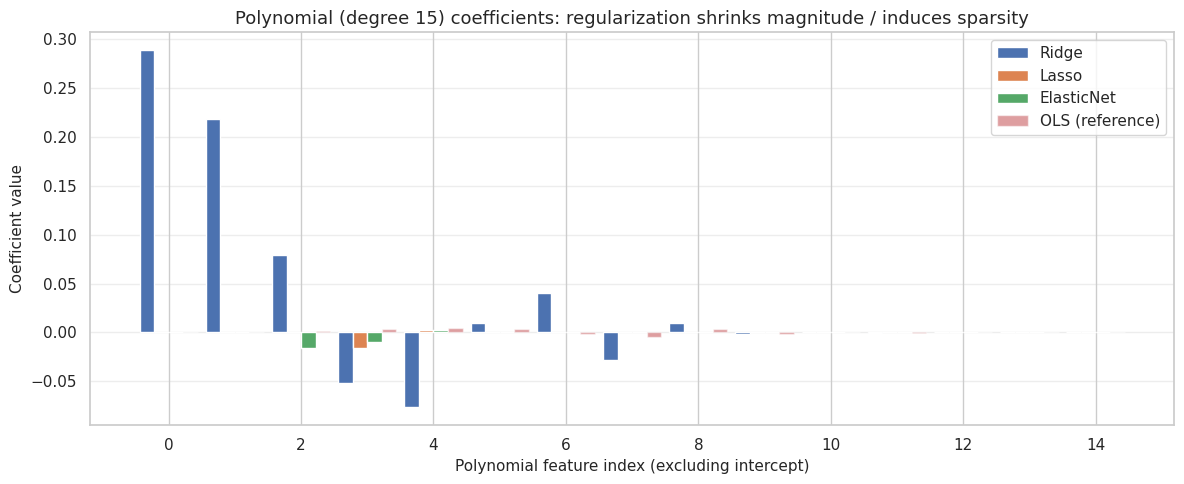

,model,test_mse,num_zero_coef (non-intercept)
1,Ridge,0.031868,0
0,OLS (poly d=15),0.032161,0
3,ElasticNet,0.058818,2
2,Lasso,0.063250,3


In [4]:
d_reg = 15
poly_reg = PolynomialFeatures(degree=d_reg, include_bias=True)
Xtr_p = poly_reg.fit_transform(X_train)
Xte_p = poly_reg.transform(X_test)

# Unregularized high-degree model (reference)
ols = LinearRegression()
ols.fit(Xtr_p, y_train)
test_mse_ols = mean_squared_error(y_test, ols.predict(Xte_p))

# Regularized models (alpha = 1.0 as requested)
ridge = Ridge(alpha=1.0, solver="svd")
lasso = Lasso(alpha=1.0, random_state=42, max_iter=200_000)
enet = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=200_000)

ridge.fit(Xtr_p, y_train)
lasso.fit(Xtr_p, y_train)
enet.fit(Xtr_p, y_train)

preds = {
    "OLS (poly d=15)": ols.predict(Xte_p),
    "Ridge": ridge.predict(Xte_p),
    "Lasso": lasso.predict(Xte_p),
    "ElasticNet": enet.predict(Xte_p),
}

mse_rows = []
for name, yhat in preds.items():
    mse_rows.append({"model": name, "test_mse": float(mean_squared_error(y_test, yhat))})

mse_df = pd.DataFrame(mse_rows).sort_values("test_mse")

# Coefficient magnitudes (exclude intercept for interpretability of shrinkage/sparsity)
feature_names = poly_reg.get_feature_names_out(["x"])
coef_frame = pd.DataFrame(
    {
        "feature": feature_names,
        "ols": ols.coef_,
        "ridge": ridge.coef_,
        "lasso": lasso.coef_,
        "elasticnet": enet.coef_,
    }
).set_index("feature")

non_intercept = coef_frame.index != "1"
cf = coef_frame.loc[non_intercept]

plt.figure(figsize=(12, 5))
xpos = np.arange(len(cf))
width = 0.22
plt.bar(xpos - 1.5 * width, cf["ridge"], width=width, label="Ridge")
plt.bar(xpos - 0.5 * width, cf["lasso"], width=width, label="Lasso")
plt.bar(xpos + 0.5 * width, cf["elasticnet"], width=width, label="ElasticNet")
plt.bar(xpos + 1.5 * width, cf["ols"], width=width, label="OLS (reference)", alpha=0.55)
plt.title("Polynomial (degree 15) coefficients: regularization shrinks magnitude / induces sparsity")
plt.ylabel("Coefficient value")
plt.xlabel("Polynomial feature index (excluding intercept)")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

zero_counts = {
    "ridge": int(np.sum(ridge.coef_[1:] == 0)),
    "lasso": int(np.sum(lasso.coef_[1:] == 0)),
    "elasticnet": int(np.sum(enet.coef_[1:] == 0)),
}

summary_reg = mse_df.copy()
summary_reg["num_zero_coef (non-intercept)"] = summary_reg["model"].map(
    {
        "Ridge": zero_counts["ridge"],
        "Lasso": zero_counts["lasso"],
        "ElasticNet": zero_counts["elasticnet"],
        "OLS (poly d=15)": int(np.sum(ols.coef_[1:] == 0)),
    }
)
summary_reg

**Interpretation:** Lasso’s **L1** penalty often produces **exact zeros** (sparse solutions), while Ridge tends to **shrink** many coefficients smoothly. Elastic Net is a compromise when features are correlated.

[↑ Back to top](#toc)

<a id="14-hyperparameter-tuning-with-cross-validation"></a>

## 1.4 Hyperparameter Tuning with Cross-Validation

Two key hyperparameters in this lab:

- **Polynomial degree** \(d\): controls model complexity / basis size.
- **Regularization strength** \\(\\alpha\\) (`alpha` in `sklearn`): controls shrinkage.

We should not tune these by peeking at the **test** set. Instead:

- `RidgeCV` / `LassoCV` efficiently tune **`alpha`** using built-in cross-validation for a fixed feature pipeline.
- `GridSearchCV` can tune **multiple** steps jointly, e.g. `poly__degree` and `ridge__alpha` inside a `Pipeline`.

Below:

1. Fit `RidgeCV` and `LassoCV` on a **degree-15 polynomial pipeline** (for illustration).
2. Fit a **joint** `GridSearchCV` on `Pipeline([("poly", PolynomialFeatures()), ("ridge", Ridge())])`.
3. Report **best parameters**, **best CV score**, and **final test MSE**.
4. Plot **coefficient paths** as a function of `alpha` for Ridge and Lasso (on a shared polynomial degree for a fair visualization).

[↑ Back to top](#toc)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.61373e-35): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.09023e-34): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.55554e-33): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.49935e-33): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.37452e-32): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

RidgeCV best alpha: 0.6951927961775606
LassoCV best alpha: 0.01


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.02146e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



GridSearchCV (Pipeline) best params: {'poly__degree': 8, 'ridge__alpha': np.float64(0.1)}
Best CV score (neg MSE): -0.03579053102610731
Final TEST MSE with best pipeline: 0.030596


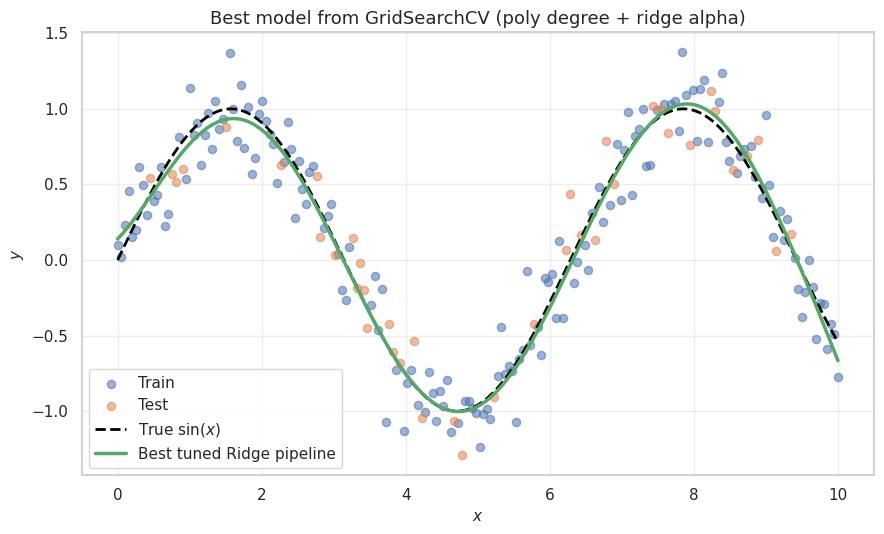

In [5]:
alphas = np.logspace(-2, 3, 20)

# --- Built-in CV for alpha (fixed high-degree basis for illustration) ---
# solver="svd" improves numerical stability for ill-conditioned polynomial designs
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(Xtr_p, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=500_000)
lasso_cv.fit(Xtr_p, y_train)

print("RidgeCV best alpha:", float(ridge_cv.alpha_))
print("LassoCV best alpha:", float(lasso_cv.alpha_))

# --- Joint tuning: polynomial degree + ridge alpha ---
pipe = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(include_bias=True)),
        ("ridge", Ridge(solver="auto")),
    ]
)

param_grid = {
    "poly__degree": [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15],
    "ridge__alpha": np.logspace(-3, 3, 10),
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

best = grid.best_estimator_
y_test_hat_best = best.predict(X_test)
test_mse_best = mean_squared_error(y_test, y_test_hat_best)

print("\nGridSearchCV (Pipeline) best params:", grid.best_params_)
print("Best CV score (neg MSE):", float(grid.best_score_))
print(f"Final TEST MSE with best pipeline: {test_mse_best:.6f}")

# Plot best tuned predictions
plt.figure(figsize=(9, 5.5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\\sin(x)$")
plt.plot(xx.ravel(), best.predict(xx), color="C2", linewidth=2.5, label="Best tuned Ridge pipeline")
plt.title("Best model from GridSearchCV (poly degree + ridge alpha)")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

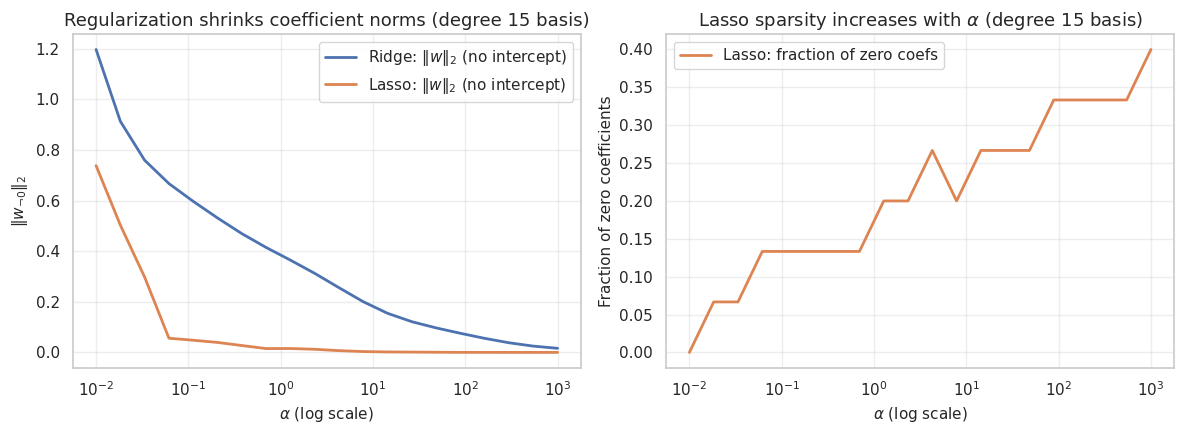

In [6]:
# Coefficient paths vs alpha (Ridge vs Lasso) on the SAME basis: degree 15
coef_paths = {"ridge": [], "lasso": []}

for a in alphas:
    rr = Ridge(alpha=float(a), solver="svd").fit(Xtr_p, y_train)
    ll = Lasso(alpha=float(a), random_state=42, max_iter=200_000).fit(Xtr_p, y_train)

    # Track L2 norm of non-intercept coefficients (variance-related complexity)
    coef_paths["ridge"].append(np.linalg.norm(rr.coef_[1:], ord=2))
    coef_paths["lasso"].append(np.linalg.norm(ll.coef_[1:], ord=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(alphas, coef_paths["ridge"], linewidth=2, label="Ridge: $\\|w\\|_2$ (no intercept)")
axes[0].plot(alphas, coef_paths["lasso"], linewidth=2, label="Lasso: $\\|w\\|_2$ (no intercept)")
axes[0].set_xscale("log")
axes[0].set_title("Regularization shrinks coefficient norms (degree 15 basis)")
axes[0].set_xlabel("$\\alpha$ (log scale)")
axes[0].set_ylabel("$\\|w_{\\neg 0}\\|_2$")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.35)

# Sparsity path for Lasso: fraction of non-intercept coefficients exactly zero
sparsity = []
for a in alphas:
    ll = Lasso(alpha=float(a), random_state=42, max_iter=200_000).fit(Xtr_p, y_train)
    sparsity.append(np.mean(ll.coef_[1:] == 0.0))

axes[1].plot(alphas, sparsity, linewidth=2, color="C1", label="Lasso: fraction of zero coefs")
axes[1].set_xscale("log")
axes[1].set_title("Lasso sparsity increases with $\\alpha$ (degree 15 basis)")
axes[1].set_xlabel("$\\alpha$ (log scale)")
axes[1].set_ylabel("Fraction of zero coefficients")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

### Tutorial summary table (sanity check)

The numeric values below depend on the fixed synthetic split, but the **ordering** should illustrate the main story: **linear underfits**, **high-degree OLS overfits**, **regularization stabilizes**, and **CV-tuned** models aim for the best test performance without manual guessing.

[↑ Back to top](#toc)

In [7]:
# Build a compact comparison table for the tutorial models discussed above
rows = []

rows.append(
    {
        "model": "LinearRegression (raw x)",
        "notes": "degree 1 basis",
        "test_mse": float(test_mse_lin),
    }
)

rows.append(
    {
        "model": "Polynomial OLS (d=15)",
        "notes": "unregularized",
        "test_mse": float(test_mse_ols),
    }
)

rows.append(
    {
        "model": "Ridge (d=15, alpha=1)",
        "notes": "hand-chosen alpha",
        "test_mse": float(mean_squared_error(y_test, ridge.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "Lasso (d=15, alpha=1)",
        "notes": "hand-chosen alpha",
        "test_mse": float(mean_squared_error(y_test, lasso.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "ElasticNet (d=15, alpha=1, l1_ratio=0.5)",
        "notes": "hand-chosen",
        "test_mse": float(mean_squared_error(y_test, enet.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "Tuned: GridSearchCV Pipeline(Ridge)",
        "notes": f"best degree={grid.best_params_['poly__degree']}, alpha={grid.best_params_['ridge__alpha']:.4g}",
        "test_mse": float(test_mse_best),
    }
)

tutorial_summary = pd.DataFrame(rows).sort_values("test_mse")
tutorial_summary

,model,notes,test_mse
5,Tuned: GridSearchCV Pipeline(Ridge),"best degree=8, alpha=0.1",0.030596
2,"Ridge (d=15, alpha=1)",hand-chosen alpha,0.031868
1,Polynomial OLS (d=15),unregularized,0.032161
4,"ElasticNet (d=15, alpha=1, l1_ratio=0.5)",hand-chosen,0.058818
3,"Lasso (d=15, alpha=1)",hand-chosen alpha,0.063250
0,LinearRegression (raw x),degree 1 basis,0.430992


<a id="part-2-coding-tasks-100-marks"></a>

# Part 2: Coding Tasks (Total **100** marks)

**Instructions**

- Complete each task in the provided code cell(s). Keep the **same** `X_train`, `X_test`, `y_train`, `y_test` from the top of the notebook.
- Your plots must include **titles**, **axis labels**, **legends** (when multiple series), and **grid**.
- Use **MSE** (`sklearn.metrics.mean_squared_error`) unless stated otherwise.

[↑ Back to top](#toc)

### Task 1: Data Exploration & Visualization (**10 marks**)

Create a **scatter plot** of the full dataset \((X, y)\) (train and test may be shown with different colors). Compute and print **basic descriptive statistics** for `y` (at minimum: mean, standard deviation, min, max) using `pandas`.

[↑ Back to top](#toc)

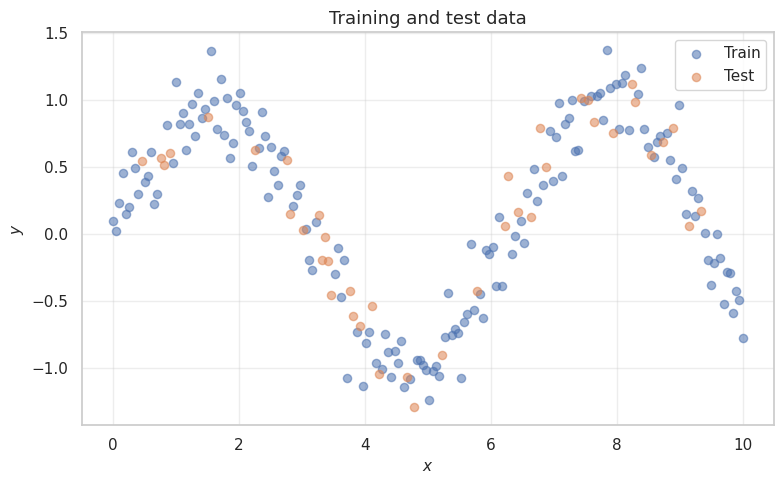

,0
count,200.000000
mean,0.171396
std,0.701055
min,-1.363989
25%,-0.410514
50%,0.290172
75%,0.739270
max,1.466334


In [11]:
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.25, size=X.shape[0])



# TODO: Your solution here
# Hints:
# - Concatenate or plot X_train/y_train and X_test/y_test separately with labels.
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.title("Training and test data")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# - Use pd.Series(y).describe() or custom printouts for required statistics.
pd.Series(y).describe()

#raise NotImplementedError("Replace this line with your Task 1 solution.")

### Task 2: Polynomial Regression without Regularization (**15 marks**)

Fit **polynomial regression** (ordinary least squares) for degrees **2, 5, and 10** using `PolynomialFeatures` + `LinearRegression`.

Report **train MSE** and **test MSE** for each degree in a small **table** (`pandas.DataFrame`). Plot **all three fits** on one figure along with the training points and the noise-free curve \(\\sin(x)\) for reference.

[↑ Back to top](#toc)

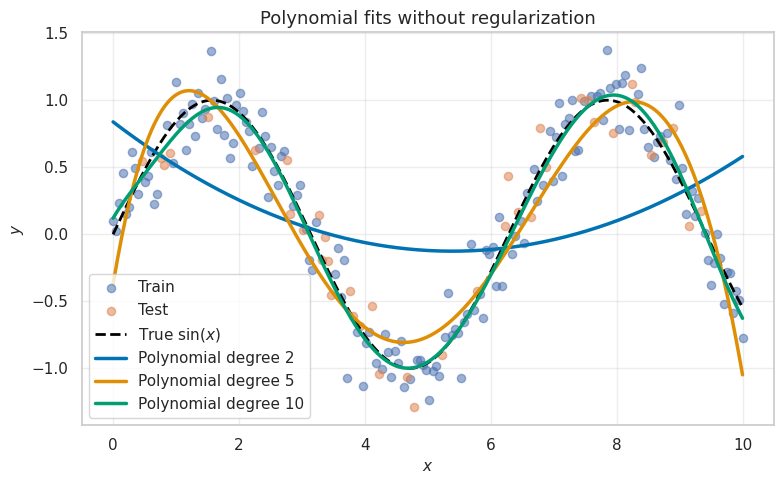

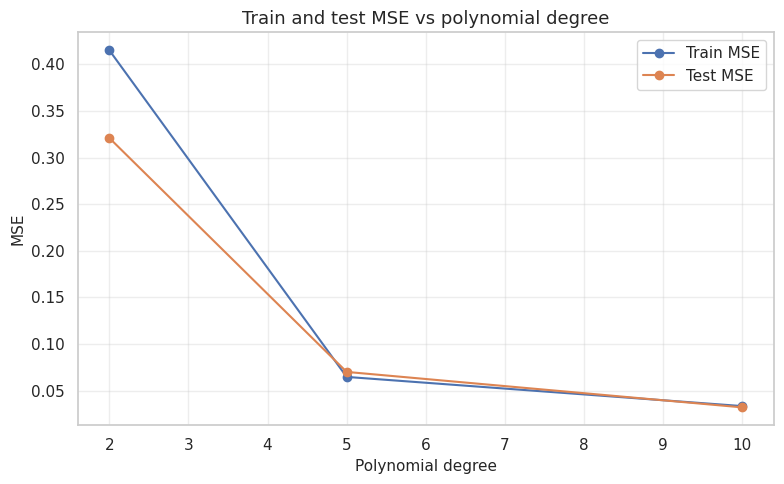

,degree,train_mse,test_mse
0,2,0.415325,0.321165
1,5,0.064708,0.070073
2,10,0.033389,0.032003


In [15]:
# TODO: Your solution here
# Hints:
# - Loop over degrees [2, 5, 10].
degree_reg = [2, 5, 10]
train_mse_by_degree = []
test_mse_by_degree = []
models_by_degree = {}

for d in degree_reg:
    poly = PolynomialFeatures(degree=d, include_bias=True)
    Xtr_p = poly.fit_transform(X_train)
    Xte_p = poly.transform(X_test)

    model = LinearRegression()
    model.fit(Xtr_p, y_train)
    models_by_degree[d] = (poly, model)

    train_mse_by_degree.append(mean_squared_error(y_train, model.predict(Xtr_p)))
    test_mse_by_degree.append(mean_squared_error(y_test, model.predict(Xte_p)))

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\\sin(x)$")

colors = sns.color_palette("colorblind", n_colors=len(degree_reg))
for i, d in enumerate(degree_reg):
    poly, model = models_by_degree[d]
    Xx = poly.transform(xx)
    plt.plot(
        xx,
        model.predict(Xx),
        color=colors[i],
        linewidth=2.5,
        label=f"Polynomial degree {d}",
    )

plt.title("Polynomial fits without regularization")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# train vs test mse vs degree

plt.figure(figsize=(8, 5))
plt.plot(degree_reg, train_mse_by_degree, "o-", label="Train MSE")
plt.plot(degree_reg, test_mse_by_degree, "o-", label="Test MSE")
plt.title("Train and test MSE vs polynomial degree")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

mse_df = pd.DataFrame(
    {
        "degree": degree_reg,
        "train_mse": train_mse_by_degree,
        "test_mse": test_mse_by_degree,
    }
)
mse_df
# - Remember: poly.fit_transform(X_train), poly.transform(X_test).
# - For plotting, generate dense xx in [0, 10] like the tutorial.


### Task 3: Ridge Regression (L2 Regularization) (**15 marks**)

Using a polynomial degree of **10** (unless you justify a different basis), train **Ridge** regression with **`alpha=1.0`**.

Plot a **bar chart** (or stem plot) of the fitted **coefficients** (you may exclude the intercept for readability). Compare **test MSE** to the **unregularized** polynomial regression of the same degree.

[↑ Back to top](#toc)

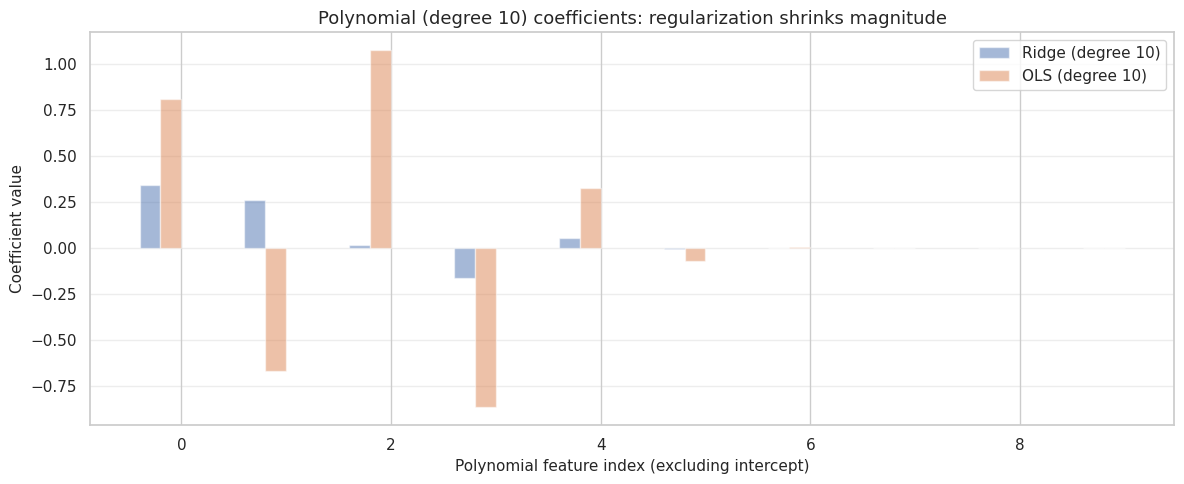

Test MSE OLS: 0.032003
Test MSE Ridge: 0.029782


In [18]:
# TODO: Your solution here
# Hints:
# - Fit LinearRegression and Ridge on the SAME polynomial design matrices.
# - Label the plot clearly; add a legend if comparing multiple coefficient vectors.
d_reg = 10
poly_reg = PolynomialFeatures(degree=d_reg, include_bias=True)
Xtr_p = poly_reg.fit_transform(X_train)
Xte_p = poly_reg.transform(X_test)

ols = LinearRegression()
ols.fit(Xtr_p, y_train)
test_mse_ols = mean_squared_error(y_test, ols.predict(Xte_p))

ridge = Ridge(alpha=1.0, solver="svd")
ridge.fit(Xtr_p, y_train)
test_mse_ridge = mean_squared_error(y_test, ridge.predict(Xte_p))

feature_names = poly_reg.get_feature_names_out(["x"])
coef_frame = pd.DataFrame(
    {
        "feature": feature_names,
        "ols": ols.coef_,
        "ridge": ridge.coef_,
    }
).set_index("feature")

non_intercept = coef_frame.index != "1"
cf = coef_frame.loc[non_intercept]

plt.figure(figsize=(12, 5))
xpos = np.arange(len(cf))
width = 0.2
plt.bar(xpos - 1.5 * width, cf["ridge"], width=width, label="Ridge (degree 10)", alpha=0.5)
plt.bar(xpos - 0.5 * width, cf["ols"], width=width, label="OLS (degree 10)", alpha=0.5)
plt.title("Polynomial (degree 10) coefficients: regularization shrinks magnitude")
plt.ylabel("Coefficient value")
plt.xlabel("Polynomial feature index (excluding intercept)")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

print(f"Test MSE OLS: {test_mse_ols:.6f}")
print(f"Test MSE Ridge: {test_mse_ridge:.6f}")




### Task 4: Lasso Regression (L1 Regularization) (**15 marks**)

Repeat Task 3 using **Lasso** with **`alpha=1.0`** on the same degree-**10** polynomial basis.

Highlight **sparsity** by reporting how many coefficients are **exactly zero** (excluding intercept is fine, but be consistent). Plot coefficients and compare **test MSE** to Ridge and OLS.

[↑ Back to top](#toc)

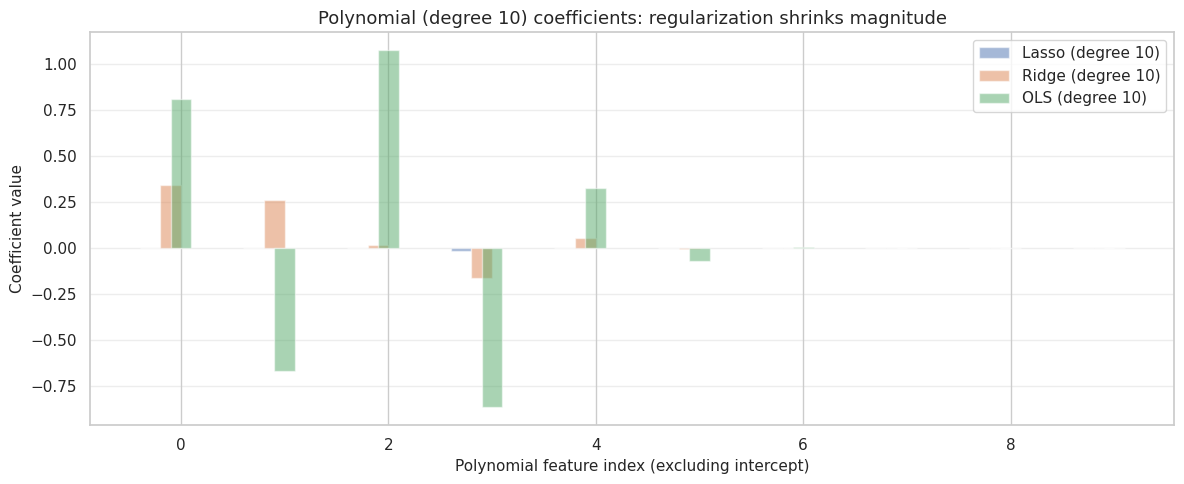

Test MSE OLS: 0.032003
Test MSE Ridge: 0.029782
Test MSE Lasso: 0.068893


In [19]:
# TODO: Your solution here
# Hints:
# - Increase max_iter if sklearn warns about convergence.
# - np.sum(np.isclose(coef, 0.0)) is more numerically stable than == for floats.
lasso = Lasso(alpha=1.0, random_state=42, max_iter=200_000)
lasso.fit(Xtr_p, y_train)
test_mse_lasso = mean_squared_error(y_test, lasso.predict(Xte_p))

preds = pd.DataFrame(
    {
        "ols": ols.predict(Xte_p),
        "lasso": lasso.predict(Xte_p),
    }
)

feature_names = poly_reg.get_feature_names_out(["x"])
coef_frame = pd.DataFrame(
    {
        "feature": feature_names,
        "ols": ols.coef_,
        "lasso": lasso.coef_,
        "ridge": ridge.coef_,
    }
).set_index("feature")

non_intercept = coef_frame.index != "1"
cf = coef_frame.loc[non_intercept]

plt.figure(figsize=(12, 5))
xpos = np.arange(len(cf))
width = 0.2
plt.bar(xpos - 1.5 * width, cf["lasso"], width=width, label="Lasso (degree 10)", alpha=0.5)
plt.bar(xpos - 0.5 * width, cf["ridge"], width=width, label="Ridge (degree 10)", alpha=0.5)
plt.bar(xpos - 0.0 * width, cf["ols"], width=width, label="OLS (degree 10)", alpha=0.5)
plt.title("Polynomial (degree 10) coefficients: regularization shrinks magnitude")
plt.ylabel("Coefficient value")
plt.xlabel("Polynomial feature index (excluding intercept)")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

print(f"Test MSE OLS: {test_mse_ols:.6f}")
print(f"Test MSE Ridge: {test_mse_ridge:.6f}")
print(f"Test MSE Lasso: {test_mse_lasso:.6f}")


### Task 5: Elastic Net Regularization (**10 marks**)

Train **ElasticNet** with **`alpha=1.0`** and **`l1_ratio=0.5`** on the same degree-**10** polynomial basis.

Produce a short written summary in **comments** (2–4 sentences) comparing **Ridge vs Lasso vs ElasticNet** on **test MSE** and **coefficient sparsity** for this setup.

[↑ Back to top](#toc)

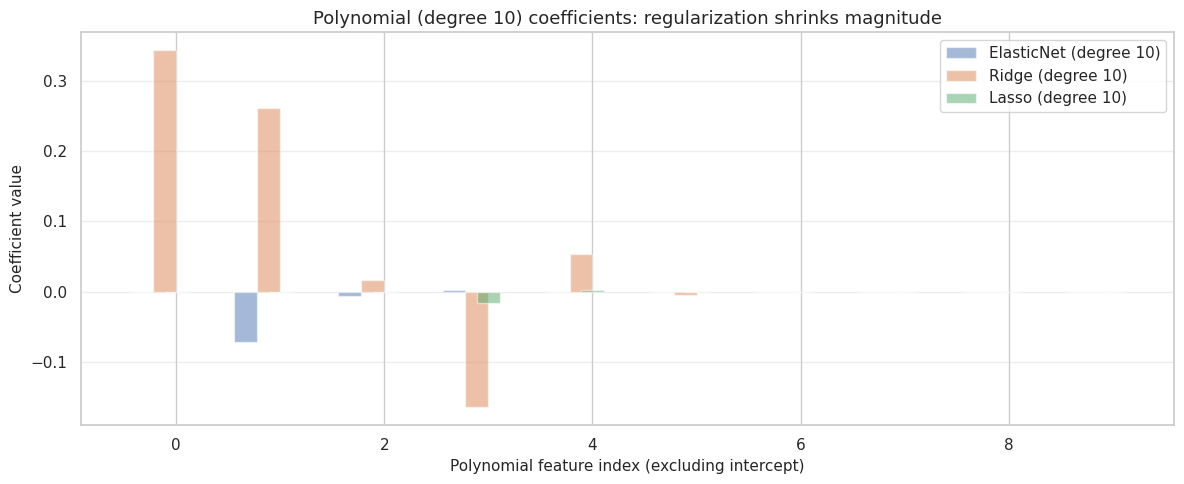

Test MSE OLS: 0.032003
Test MSE Ridge: 0.029782
Test MSE Lasso: 0.068893
Test MSE ElasticNet: 0.138566


In [21]:
# TODO: Your solution here
enet = ElasticNet(alpha=1.0, l1_ratio=0.5)
enet.fit(Xtr_p, y_train)
test_mse_enet = mean_squared_error(y_test, enet.predict(Xte_p))

preds = pd.DataFrame(
    {
        "ols": ols.predict(Xte_p),
        "lasso": lasso.predict(Xte_p),
        "enet": enet.predict(Xte_p),
    }
)

feature_names = poly_reg.get_feature_names_out(["x"])
coef_frame = pd.DataFrame(
    {
        "feature": feature_names,
        "ols": ols.coef_,
        "lasso": lasso.coef_,
        "ridge": ridge.coef_,
        "enet": enet.coef_,
    }
).set_index("feature")

non_intercept = coef_frame.index != "1"
cf = coef_frame.loc[non_intercept]

plt.figure(figsize=(12, 5))
xpos = np.arange(len(cf))
width = 0.22
plt.bar(xpos - 1.5 * width, cf["enet"], width=width, label="ElasticNet (degree 10)", alpha=0.5)
plt.bar(xpos - 0.5 * width, cf["ridge"], width=width, label="Ridge (degree 10)", alpha=0.5)
plt.bar(xpos - 0.0 * width, cf["lasso"], width=width, label="Lasso (degree 10)", alpha=0.5)
plt
plt.title("Polynomial (degree 10) coefficients: regularization shrinks magnitude")
plt.ylabel("Coefficient value")
plt.xlabel("Polynomial feature index (excluding intercept)")
plt.legend(loc="upper right")
plt
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

print(f"Test MSE OLS: {test_mse_ols:.6f}")
print(f"Test MSE Ridge: {test_mse_ridge:.6f}")
print(f"Test MSE Lasso: {test_mse_lasso:.6f}")
print(f"Test MSE ElasticNet: {test_mse_enet:.6f}")

### Task 6: Automated Hyperparameter Tuning (**35 marks**)

Use **all three** methods below and report the selected hyperparameters and **test MSE**:

1. **`RidgeCV`** to tune `alpha` for a **degree-10** polynomial basis.
2. **`LassoCV`** to tune `alpha` for a **degree-10** polynomial basis.
3. **`GridSearchCV`** on a `Pipeline([("poly", PolynomialFeatures()), ("ridge", Ridge())])` to jointly tune **`poly__degree`** and **`ridge__alpha`**.

Present results in a **`DataFrame`**. Include at least one **plot** of the best tuned prediction curve vs data.

[↑ Back to top](#toc)

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1451/543368234.py:45: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\sin(x)$")


Ridge best alpha: 0.30538555088334157
Lasso best alpha: 0.01


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.41389e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.238e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.27825e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.32026e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.31742e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3


GridSearchCV (Pipline) best params: {'poly__degree': 10, 'ridge__alpha': np.float64(0.23101297000831605)}
GridSearchCV (Pipline) best MSE: 0.036057554291755035
GridSearchCV (Pipline) test MSE: 0.03099324709975444


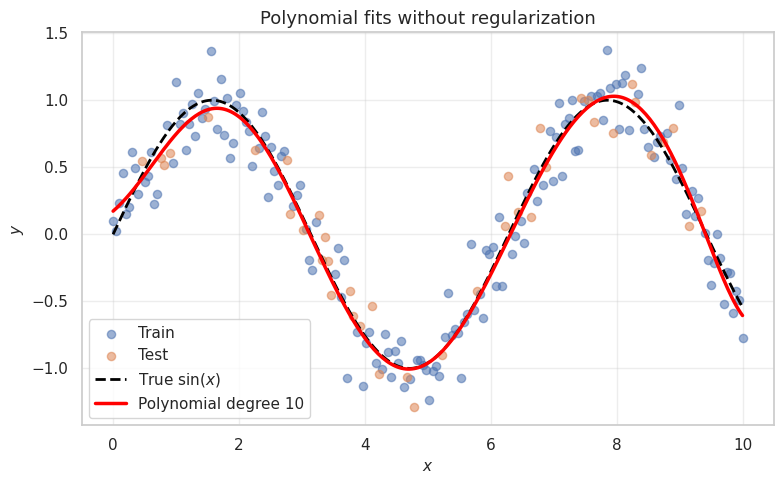

In [24]:
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), store_cv_values=True)
ridge_cv.fit(Xtr_p, y_train)
test_mse_ridge_cv = mean_squared_error(y_test, ridge_cv.predict(Xte_p))

lasso_cv = LassoCV(alphas=alphas, cv=10, max_iter=200_000)
lasso_cv.fit(Xtr_p, y_train)

print("Ridge best alpha:", float(ridge_cv.alpha_))
print("Lasso best alpha:", float(lasso_cv.alpha_))

pipe = Pipeline(
    [
        ("poly", PolynomialFeatures(include_bias=True)),
        ("ridge", Ridge()),
    ]
)

param_grid = {
    "poly__degree": [2, 5, 10],
    "ridge__alpha": np.logspace(-3, 3, 100),
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=10,
    scoring="neg_mean_squared_error",
    return_train_score=True,
)

grid.fit(X_train, y_train)

best = grid.best_estimator_
test_mse_best = mean_squared_error(y_test, best.predict(X_test))


print("\nGridSearchCV (Pipline) best params:", grid.best_params_)
print("GridSearchCV (Pipline) best MSE:", float(-grid.best_score_))
print("GridSearchCV (Pipline) test MSE:", float(test_mse_best))


plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\sin(x)$")
plt.plot(
    xx,
    best.predict(xx),
    color="red",
    linewidth=2.5,
    label=f"Polynomial degree {grid.best_params_['poly__degree']}",
)
plt.title("Polynomial fits without regularization")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

<a id="bonus-section-10-extra-marks"></a>

## Bonus Section (**10% extra marks** — complete **all 5** for full bonus)


<a id="conclusion"></a>

## Conclusion

Take 5–10 minutes to reflect (write 2–3 sentences in your report):

- Where did **linear** regression fail, and what **nonlinearity** mechanism fixed it?

Linear regression failed when the relationship was curved/nonlinear, and adding polynomial features fixed it by letting the model bend to fit the data.


- What symptoms indicated **overfitting**, and which **metric split** helped you detect it?

Overfitting symptoms were a large gap between high training score and low validation score, detected by the train/validation metric split.

- How do **Ridge**, **Lasso**, and **Elastic Net** differ in their **penalties** and typical **coefficient patterns**?

Ridge shrinks all coefficients small but nonzero (L2), Lasso drives some to exactly zero (L1, feature selection), Elastic Net combines both penalties for correlated features.

- Why is **cross-validation** preferable to repeatedly evaluating on the **test** set while tuning?

Cross-validation is preferable because repeatedly peeking at the test set leaks information into model selection, making it no longer a truly independent evaluation.

- What is one **real-world caution** when using high-degree polynomials without careful scaling or regularization?

Real-world caution: High-degree polynomial terms explode in magnitude for large inputs, causing wild oscillations and numerical instability without scaling or regularization.
